In [1]:
import torch.nn as nn
from collections import OrderedDict
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets.mnist import MNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch

class C1(nn.Module):
    def __init__(self):
        super(C1, self).__init__()

        self.c1 = nn.Sequential(OrderedDict([
            ('c1', nn.Conv2d(1, 6, kernel_size=(5, 5))),
            ('relu1', nn.ReLU()),
            ('s1', nn.MaxPool2d(kernel_size=(2, 2), stride=2))
        ]))

    def forward(self, img):
        output = self.c1(img)
        return output


class C2(nn.Module):
    def __init__(self):
        super(C2, self).__init__()

        self.c2 = nn.Sequential(OrderedDict([
            ('c2', nn.Conv2d(6, 16, kernel_size=(5, 5))),
            ('relu2', nn.ReLU()),
            ('s2', nn.MaxPool2d(kernel_size=(2, 2), stride=2))
        ]))

    def forward(self, img):
        output = self.c2(img)
        return output


class C3(nn.Module):
    def __init__(self):
        super(C3, self).__init__()
        self.c3 = nn.Sequential(OrderedDict([
            ('c3', nn.Conv2d(16, 120, kernel_size=(5, 5))),
            ('relu3', nn.ReLU())
        ]))

    def forward(self, img):
        output = self.c3(img)
        return output


class F4(nn.Module):
    def __init__(self):
        super(F4, self).__init__()

        self.f4 = nn.Sequential(OrderedDict([
            ('f4', nn.Linear(120, 84)),
            ('relu4', nn.ReLU())
        ]))

    def forward(self, img):
        output = self.f4(img)
        return output


class F5(nn.Module):
    def __init__(self):
        super(F5, self).__init__()

        self.f5 = nn.Sequential(OrderedDict([
            ('f5', nn.Linear(84, 10)),
            ('sig5', nn.LogSoftmax(dim=-1))
        ]))

    def forward(self, img):
        output = self.f5(img)
        return output


class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()

        self.c1 = C1()
        self.c2_1 = C2()
        self.c2_2 = C2()
        self.c3 = C3()
        self.f4 = F4()
        self.f5 = F5()

    def forward(self, img):
        output = self.c1(img)

        x = self.c2_1(output)
        output = self.c2_2(output)

        output += x

        output = self.c3(output)
        output = output.view(img.size(0), -1)
        output = self.f4(output)
        output = self.f5(output)
        return output

In [2]:
net = LeNet5()
c1=net.c1
print('Parametros de la primera convolución 2D')
print(c1.c1.c1.weight.shape, c1.c1.c1.bias.shape)

c2=net.c2_1
print('Parametros de la segunda convolución 2D')
print(c2.c2.c2.weight.shape, c2.c2.c2.bias.shape)

c3=net.c3
print('Parametros de la TERCERA convolución 2D')
print(c3.c3.c3.weight.shape, c3.c3.c3.bias.shape)


Parametros de la primera convolución 2D
torch.Size([6, 1, 5, 5]) torch.Size([6])
Parametros de la segunda convolución 2D
torch.Size([16, 6, 5, 5]) torch.Size([16])
Parametros de la TERCERA convolución 2D
torch.Size([120, 16, 5, 5]) torch.Size([120])


In [3]:
data_train = MNIST('./data', train=True, download=True,
                       transform=transforms.Compose([
                      transforms.Resize((32, 32)),
                      transforms.ToTensor()]))
data_test = MNIST('./data', train=False,
                       transform=transforms.Compose([
                      transforms.Resize((32, 32)),
                      transforms.ToTensor()]))
data_train_loader = DataLoader(data_train, batch_size=256, shuffle=True)
data_test_loader = DataLoader(data_test, batch_size=1024)

100%|██████████| 9.91M/9.91M [00:18<00:00, 525kB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 323kB/s]
100%|██████████| 1.65M/1.65M [00:12<00:00, 133kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.52MB/s]


60000
torch.Size([1, 32, 32])


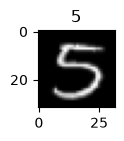

In [4]:
import matplotlib.pyplot as plt
import numpy as np
x,y=data_train[np.random.randint(low=0, high=len(data_train))]
plt.figure(figsize=(1,1))
plt.imshow(x.numpy().squeeze(0), cmap='gray')
plt.title(str(y))
print(len(data_train))
print(x.shape)

In [5]:
net = LeNet5()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=2e-3)

cur_batch_win = None
cur_batch_win_opts = {
    'title': 'Epoch Loss Trace',
    'xlabel': 'Batch Number',
    'ylabel': 'Loss',
    'width': 1200,
    'height': 600,
}

def train(epoch):
    global cur_batch_win
    net.train()
    loss_list, batch_list = [], []
    for i, (images, labels) in enumerate(data_train_loader):
        optimizer.zero_grad()
        output = net(images)
        loss = criterion(output, labels)
        loss_list.append(loss.detach().cpu().item())
        batch_list.append(i+1)
        if i % 10 == 0:
            print('Train - Epoch %d, Batch: %d, Loss: %f' % (epoch, i, loss.detach().cpu().item()))
        loss.backward()
        optimizer.step()

def test():
    net.eval()
    total_correct = 0
    avg_loss = 0.0
    for i, (images, labels) in enumerate(data_test_loader):
        output = net(images)
        avg_loss += criterion(output, labels).sum()
        pred = output.detach().max(1)[1]
        total_correct += pred.eq(labels.view_as(pred)).sum()

    avg_loss /= len(data_test)
    print('Test Avg. Loss: %f, Accuracy: %f' % (avg_loss.detach().cpu().item(), float(total_correct) / len(data_test)))


def train_and_test(epoch):
    print('Training...')
    train(epoch)
    print('Testing...')
    test()

    dummy_input = torch.randn(1, 1, 32, 32, requires_grad=True)

for e in range(1, 4):
    train_and_test(e)


Training...
Train - Epoch 1, Batch: 0, Loss: 2.300980
Train - Epoch 1, Batch: 10, Loss: 2.097379
Train - Epoch 1, Batch: 20, Loss: 0.962280
Train - Epoch 1, Batch: 30, Loss: 0.576994
Train - Epoch 1, Batch: 40, Loss: 0.438163
Train - Epoch 1, Batch: 50, Loss: 0.442843
Train - Epoch 1, Batch: 60, Loss: 0.317514
Train - Epoch 1, Batch: 70, Loss: 0.282439
Train - Epoch 1, Batch: 80, Loss: 0.345465
Train - Epoch 1, Batch: 90, Loss: 0.246773
Train - Epoch 1, Batch: 100, Loss: 0.170780
Train - Epoch 1, Batch: 110, Loss: 0.202235
Train - Epoch 1, Batch: 120, Loss: 0.214882
Train - Epoch 1, Batch: 130, Loss: 0.109550
Train - Epoch 1, Batch: 140, Loss: 0.185328
Train - Epoch 1, Batch: 150, Loss: 0.116657
Train - Epoch 1, Batch: 160, Loss: 0.116069
Train - Epoch 1, Batch: 170, Loss: 0.197749
Train - Epoch 1, Batch: 180, Loss: 0.088658
Train - Epoch 1, Batch: 190, Loss: 0.088290
Train - Epoch 1, Batch: 200, Loss: 0.073278
Train - Epoch 1, Batch: 210, Loss: 0.114409
Train - Epoch 1, Batch: 220, Lo

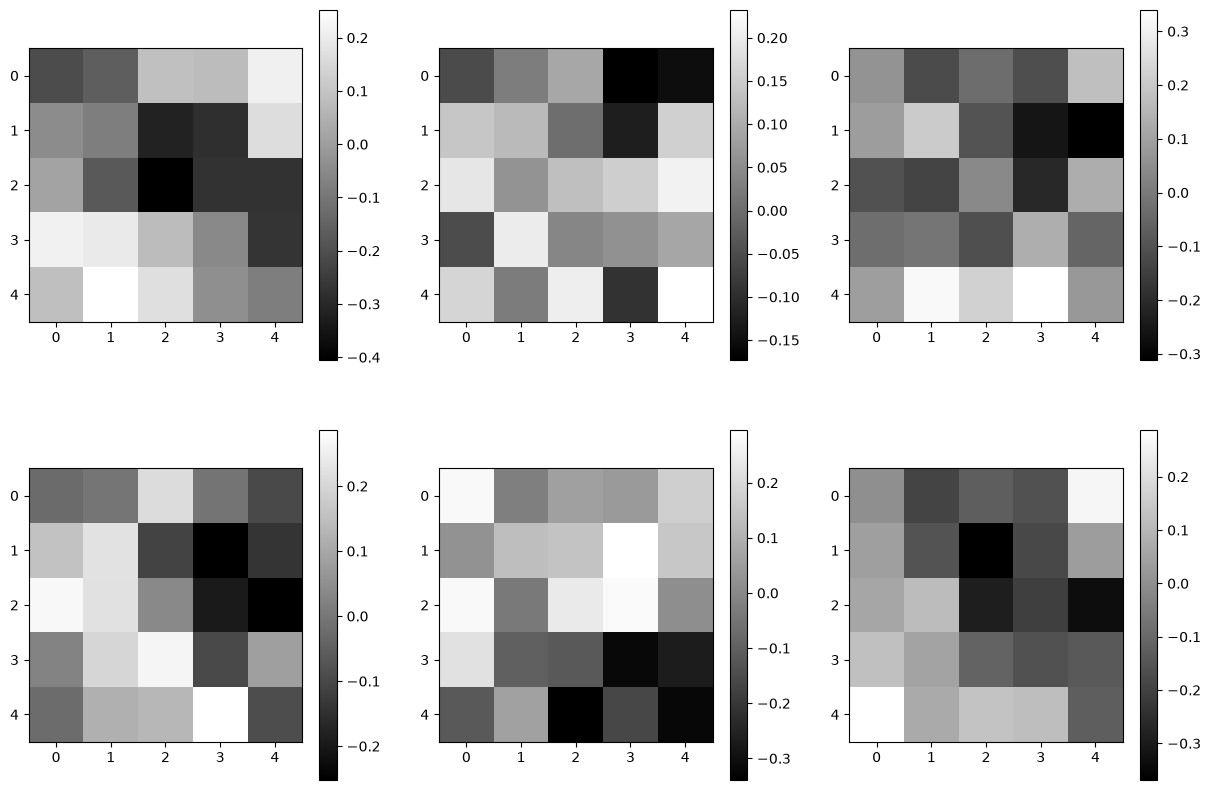

In [9]:
net.c1.c1.c1.weight.shape
import matplotlib.pyplot as plt
plt.figure(figsize=(15,10))
for i in range(6):
  plt.subplot(2,3,i+1)
  plt.imshow(net.c1.c1.c1.weight[i,0].detach().numpy(), cmap='gray')
  #plt.imshow(net.c2_1.c2.c2.weight[i,0].detach().numpy(), cmap='gray')
  plt.colorbar()

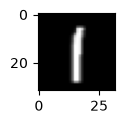

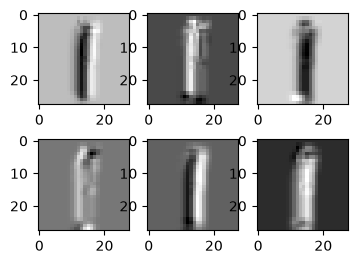

In [10]:
x,y=data_train[np.random.randint(low=0, high=len(data_train))]
y=c1.c1.c1(x.unsqueeze(0))
y.shape
plt.figure(figsize=(1,1))
plt.imshow(np.moveaxis(x.numpy(),0,2), cmap='gray')
plt.figure(figsize=(4,3))
for i in range(6):
  plt.subplot(2,3,i+1)
  plt.imshow(y.detach().numpy()[0,i,:,:], cmap='gray')


torch.Size([1, 6, 14, 14])


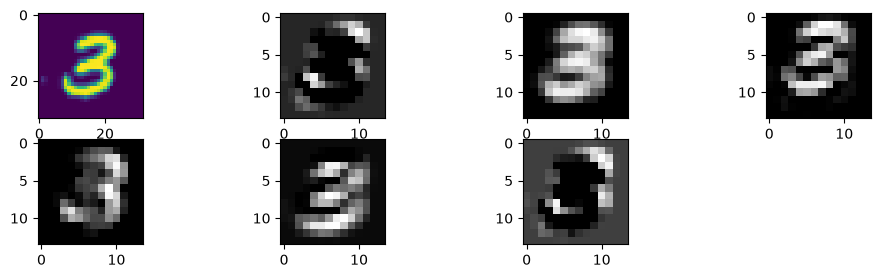

In [12]:
import numpy as np
x,y=data_train[np.random.randint(low=0, high=len(data_train))]
plt.figure(figsize=(12,3))
plt.subplot(2,4,1)
plt.imshow(x.numpy().squeeze(0))
x2=x.unsqueeze(0)
x2.shape
output=net.c1.c1(x2)
#output=net.c2_1.c2(output)
print(output.shape)
for i in range(6):
  plt.subplot(2,4,i+2)
  img=output.detach().numpy()[0,i,:,:]
  plt.imshow(img, cmap='gray')